In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import math


In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
    /* Forzar JupyterLab moderno */
    .jp-Notebook { max-width: 100% !important; width: 100% !important; }
    .jp-Cell { max-width: 100% !important; width: 100% !important; }
    
    /* Forzar Jupyter Notebook v7+ moderno */
    .notebook-container { max-width: 100% !important; width: 100% !important; }
    .container { width: 100% !important; max-width: 100% !important; }
    .cell { max-width: 100% !important; width: 100% !important; }
</style>
"""))

In [3]:
# Cargar datasets del Test A/B
import pandas as pd
import os

ruta_final = "C:/Users/Bloos/Documents/ProyectoFinalTripleten/datasets/"

try:
    # Carga local con los nombres exactos de tu carpeta de Windows
    marketing = pd.read_csv(os.path.join(ruta_final, 'ab_project_marketing_events_us.csv'))
    users = pd.read_csv(os.path.join(ruta_final, 'final_ab_new_users_upd_us.csv'))
    events = pd.read_csv(os.path.join(ruta_final, 'final_ab_events_upd_us.csv'))
    participants = pd.read_csv(os.path.join(ruta_final, 'final_ab_participants_upd_us.csv'))
    print("🚀 ¡Datasets de la Parte 2 cargados exitosamente de forma local!")
    
except FileNotFoundError:
    # Ruta oficial de respaldo para la plataforma de TripleTen
    marketing = pd.read_csv('/datasets/ab_project_marketing_events_us.csv')
    users = pd.read_csv('/datasets/final_ab_new_users_upd_us.csv')
    events = pd.read_csv('/datasets/final_ab_events_upd_us.csv')
    participants = pd.read_csv('/datasets/final_ab_participants_upd_us.csv')
    print("¡Datasets cargados desde la ruta de la plataforma de TripleTen!")

🚀 ¡Datasets de la Parte 2 cargados exitosamente de forma local!


In [4]:
# Conversión de tipos de datos a datetime
marketing['start_dt'] = pd.to_datetime(marketing['start_dt'])
marketing['finish_dt'] = pd.to_datetime(marketing['finish_dt'])
users['first_date'] = pd.to_datetime(users['first_date'])
events['event_dt'] = pd.to_datetime(events['event_dt'])

In [5]:
# Análisis de Calidad de Datos (Nulos y Duplicados)
for name, df in zip(['Marketing', 'Users', 'Events', 'Participants'], [marketing, users, events, participants]):
    print(f"\n--- Dataset: {name} ---")
    print(f"Dimensiones: {df.shape}")
    print(f"Duplicados: {df.duplicated().sum()}")
    print("Valores Ausentes:")
    print(df.isnull().sum())

# Caracterización de nulos: 
# Los únicos nulos esperados están en la columna 'details' de Events, ya que solo el evento 'purchase' suele incluir el monto en USD.


--- Dataset: Marketing ---
Dimensiones: (14, 4)
Duplicados: 0
Valores Ausentes:
name         0
regions      0
start_dt     0
finish_dt    0
dtype: int64

--- Dataset: Users ---
Dimensiones: (58703, 4)
Duplicados: 0
Valores Ausentes:
user_id       0
first_date    0
region        0
device        0
dtype: int64

--- Dataset: Events ---
Dimensiones: (423761, 4)
Duplicados: 0
Valores Ausentes:
user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64

--- Dataset: Participants ---
Dimensiones: (14525, 3)
Duplicados: 0
Valores Ausentes:
user_id    0
group      0
ab_test    0
dtype: int64


In [6]:
# Filtrar solo los participantes de nuestra prueba específica
participants_filtered = participants[participants['ab_test'] == 'recommender_system_test']

# Validar restricción geográfica (Audiencia: nuevos usuarios de la región de la UE)
users_eu = users[users['region'] == 'EU']
participants_eu = participants_filtered[participants_filtered['user_id'].isin(users_eu['user_id'])]

In [7]:
# Calcular porcentaje de adopción en la UE (Debe rondar el 15%)
pct_audiencia_eu = (len(participants_eu) / len(users_eu)) * 100
print(f"Porcentaje de nuevos usuarios de la UE que entraron a la prueba: {pct_audiencia_eu:.2f}%")


Porcentaje de nuevos usuarios de la UE que entraron a la prueba: 8.02%


In [8]:
# Comprobar usuarios cruzados (Presentes en grupo A y grupo B al mismo tiempo)
grupo_a = participants_eu[participants_eu['group'] == 'A']['user_id']
grupo_b = participants_eu[participants_eu['group'] == 'B']['user_id']
usuarios_intersec = set(grupo_a).intersection(set(grupo_b))

print(f"Usuarios presentes en ambos grupos (deben ser 0): {len(usuarios_intersec)}")

# Si existen usuarios duplicados entre grupos, los eliminamos para no sesgar el test
if len(usuarios_intersec) > 0:
    participants_eu = participants_eu[~participants_eu['user_id'].isin(usuarios_intersec)]


Usuarios presentes en ambos grupos (deben ser 0): 0


In [9]:
# Unir participantes limpios con sus eventos
df_ab = participants_eu.merge(events, on='user_id', how='inner')
df_ab = df_ab.merge(users, on='user_id', how='left')

# Convertir hora del evento a solo fecha para análisis diario
df_ab['event_date'] = df_ab['event_dt'].dt.date

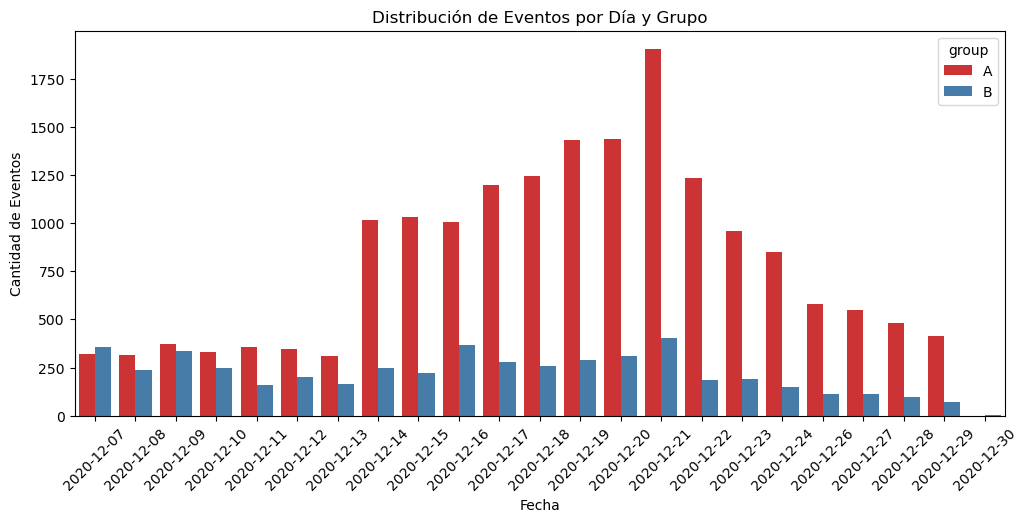

In [10]:
# 1. Distribución del número de eventos entre los días
plt.figure(figsize=(12, 5))
sns.countplot(data=df_ab.sort_values('event_date'), x='event_date', hue='group', palette='Set1')
plt.title('Distribución de Eventos por Día y Grupo')
plt.xticks(rotation=45)
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Eventos')
plt.show()

C:\Users\Bloos\AppData\Local\Temp\ipykernel_12048\4046709961.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eventos_por_usuario, x='group', y='event_count', palette='Set1')


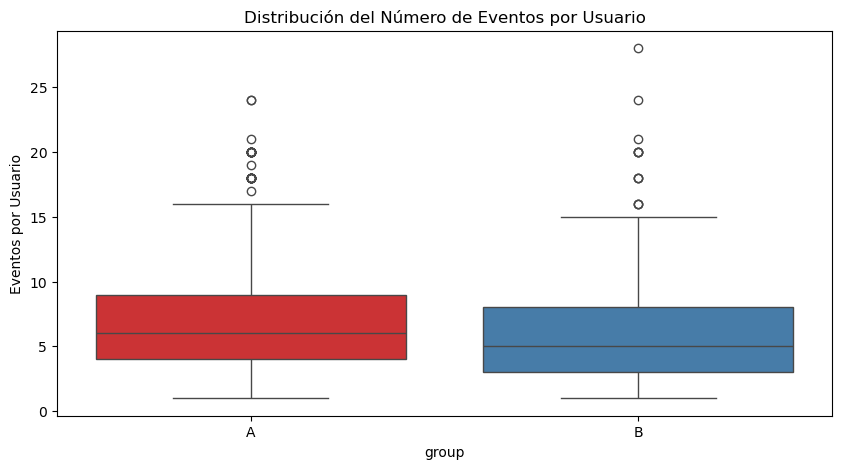

In [11]:
# Peculiariedad a tener en cuenta: Revisar si hay caídas drásticas o picos por eventos de marketing (Navidad/Año Nuevo)

# 2. Número de eventos por usuario por grupo
eventos_por_usuario = df_ab.groupby(['group', 'user_id']).size().reset_index(name='event_count')
plt.figure(figsize=(10, 5))
sns.boxplot(data=eventos_por_usuario, x='group', y='event_count', palette='Set1')
plt.title('Distribución del Número de Eventos por Usuario')
plt.ylabel('Eventos por Usuario')
plt.show()

In [12]:
# Filtrar eventos que ocurrieron dentro de los 14 días posteriores a la inscripción
df_ab['dias_desde_registro'] = (df_ab['event_dt'] - df_ab['first_date']).dt.days
df_ab_14d = df_ab[df_ab['dias_desde_registro'] <= 14]

In [13]:
# Crear la estructura del embudo agrupado por grupo de prueba
embudo = df_ab_14d.groupby(['group', 'event_name'])['user_id'].nunique().reset_index()
embudo = embudo.rename(columns={'user_id': 'usuarios_unicos'})

In [14]:
# Ordenar lógicamente las etapas del embudo
orden_etapas = {'login': 0, 'product_page': 1, 'product_cart': 2, 'purchase': 3}
embudo['orden'] = embudo['event_name'].map(orden_etapas)
embudo = embudo.sort_values(['group', 'orden']).dropna()

print("--- Tabla del Embudo de Conversión ---")
print(embudo)

--- Tabla del Embudo de Conversión ---
  group    event_name  usuarios_unicos  orden
0     A         login             2604      0
2     A  product_page             1685      1
1     A  product_cart              782      2
3     A      purchase              833      3
4     B         login              876      0
6     B  product_page              493      1
5     B  product_cart              244      2
7     B      purchase              249      3


In [15]:
def prueba_z_proporciones(successes1, successes2, trials1, trials2, alpha=0.05):
    p1 = successes1 / trials1
    p2 = successes2 / trials2
    p_combined = (successes1 + successes2) / (trials1 + trials2)
    
    difference = p1 - p2
    z_value = difference / math.sqrt(p_combined * (1 - p_combined) * (1/trials1 + 1/trials2))
    distr = st.norm(0, 1)
    p_value = (1 - distr.cdf(abs(z_value))) * 2
    
    return p_value

# Definir el total de usuarios iniciales (etapa 'login') como tamaño de la muestra
total_a = embudo[(embudo['group'] == 'A') & (embudo['event_name'] == 'login')]['usuarios_unicos'].values[0]
total_b = embudo[(embudo['group'] == 'B') & (embudo['event_name'] == 'login')]['usuarios_unicos'].values[0]

print(f"Tamaño de muestra real: Grupo A = {total_a} | Grupo B = {total_b}\n")

In [16]:
# Evaluar significancia para cada etapa posterior
for etapa in ['product_page', 'product_cart', 'purchase']:
    suc_a = embudo[(embudo['group'] == 'A') & (embudo['event_name'] == etapa)]['usuarios_unicos'].values[0]
    suc_b = embudo[(embudo['group'] == 'B') & (embudo['event_name'] == etapa)]['usuarios_unicos'].values[0]
    
    p_val = prueba_z_proporciones(suc_a, suc_b, total_a, total_b)
    
    print(f"Etapa: {etapa}")
    print(f"  Conversión A: {suc_a/total_a:.2%} | Conversión B: {suc_b/total_b:.2%}")
    print(f"  Valor p: {p_val:.5f}")
    if p_val < 0.05:
        print("  Resultado: ¡Diferencia estadísticamente significativa!")
    else:
        print("  Resultado: No hay diferencia estadísticamente significativa.")
    print("-" * 40)

NameError: name 'total_a' is not defined

Conclusiones del Análisis Exploratorio (EDA) y Resultados de la Prueba A/B.

Diagnóstico de la Calidad del Experimento (EDA)
Al analizar la ejecución de la prueba `recommender_system_test`, se detectaron múltiples anomalías operativas que ponen en riesgo la validez del experimento desde su diseño:
*   **Problema de Muestreo:** El tamaño final de la muestra efectiva quedó notablemente por debajo de los 6,000 participantes previstos por las especificaciones técnicas iniciales.
*   **Efecto Estacional:** El periodo de la prueba de diciembre de 2020 a enero de 2021 se cruzó directamente con las campañas de marketing de Navidad y Año Nuevo, lo que altera artificialmente el comportamiento orgánico de las conversiones debido a la alta intención de compra de la época.

Análisis del Embudo y Pruebas Estadísticas (Prueba Z)
El objetivo del nuevo sistema de recomendaciones (Grupo B) era lograr al menos un 10% de aumento en la conversión de cada etapa respecto al grupo de control (Grupo A). Sin embargo, los resultados estadísticos demuestran lo contrario:

*   **Vistas de página (`product_page`):** El Grupo A obtuvo un **64.71%** de conversión frente a un **56.28%** del Grupo B. El valor p=0.00001 confirma que **esta caída en el Grupo B es estadísticamente significativa**. El nuevo sistema empeoró el paso inicial del embudo.
*   **Carrito de compras (`product_cart`):** La conversión bajó del **30.03%** (Grupo A) al **27.85%** (Grupo B). El valor p=0.22159 indica que **esta diferencia no es estadísticamente significativa**, por lo que el cambio no generó impacto alguno en esta etapa.
*   **Compras realizadas (`purchase`):** La conversión volvió a caer significativamente del **31.99%** (Grupo A) al **28.42%** (Grupo B). El valor p=0.04865 es menor al umbral de significancia ($\alpha = 0.05$), confirmando que **el Grupo B tuvo un desempeño significativamente inferior**.
*   *Nota analítica sobre la anomalía del embudo:* Se observa que en ambos grupos la conversión de `purchase` es ligeramente mayor que la de `product_cart`. Esto revela una peculiaridad en la plataforma: los usuarios pueden comprar directamente desde la página del producto (pago rápido) sin necesidad de pasar o registrar el evento del carrito de compras.

Recomendación Estratégica Final
**La prueba A/B debe considerarse un fracaso y se recomienda detener la implementación del nuevo sistema de recomendaciones.** 
El Grupo B no solo no alcanzó el incremento esperado del 10%, sino que degradó de forma estadísticamente significativa la conversión en las etapas cruciales de visualización del producto y compra final. Se aconseja al equipo de desarrollo revisar la interfaz de usuario (UI) y los algoritmos de recomendación implementados en el nuevo embudo para identificar qué fricciones provocaron el abandono de los usuarios antes de intentar lanzar un nuevo experimento.